In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import numpy as np
import pandas as pd
from tokenizers import Tokenizer
from functools import reduce
from datasets import load_dataset
import matplotlib.pyplot as plt
from IPython.display import clear_output
import uuid

In [2]:
ds = load_dataset("flydexo/tinyfontaine")
train_data = '\n'.join(ds['train']['text'])
valid_data = '\n'.join(ds['validation']['text'])

In [3]:
tokenizer = Tokenizer.from_file("tokenizer.json")

In [4]:
device = torch.device('cuda')

In [5]:
seq_len = 72          # Must be large to capture rhymes and meter
vocab_size = tokenizer.get_vocab_size()     # BPE target size
n_hidden = 256        # Brain power for 17th-century French
n_layers = 3          # Network depth
p = 0.4          # Dropout
batch_size = 64       # Increased to 64 for SGD stability!
alpha = 0.1           # AR 
beta = 0.05           # TAR
momentum = 0.9        # Standard momentum
lr = 1              # Starting Learning Rate
epochs = 50
max_lr = 5e-3
wd = 0.05

In [6]:
class LM(nn.Module):
    def __init__(self, vocab_size, n_hidden, n_layers, p_dropout):
        super().__init__()
        self.n_hidden = n_hidden
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(vocab_size, n_hidden)
        
        self.lstm = nn.LSTM(
            input_size=n_hidden, 
            hidden_size=n_hidden, 
            num_layers=n_layers, 
            dropout=p_dropout if n_layers > 1 else 0,
            batch_first=True 
        )
        
        self.dropout = nn.Dropout(p_dropout)
        
        self.fc = nn.Linear(n_hidden, vocab_size)
        
        self.fc.weight = self.embedding.weight
        
        self.hidden_state = None

    def forward(self, x):
        bs = x.size(0)
        
        if self.hidden_state is None or self.hidden_state[0].size(1) != bs:
            weight = next(self.parameters()).data
            self.hidden_state = (weight.new_zeros(self.n_layers, bs, self.n_hidden),
                                 weight.new_zeros(self.n_layers, bs, self.n_hidden))
            
        emb = self.dropout(self.embedding(x))
        
        out, self.hidden_state = self.lstm(emb, self.hidden_state)
        self.hidden_state = (self.hidden_state[0].detach(), self.hidden_state[1].detach())
        
        out = self.dropout(out)
        logits = self.fc(out) 
        
        return logits

    def reset(self):
        self.hidden_state = None

In [7]:
loss_fn = nn.CrossEntropyLoss()

In [8]:
class FontaineDataset(torch.utils.data.IterableDataset):
    def __init__(self, data, seq_len, batch_size):
        super().__init__()
        text_tensor = torch.tensor(tokenizer.encode(data).ids, device=device)
        
        n_tokens = len(text_tensor) - 1 
        tokens_per_stream = n_tokens // batch_size
        
        x_data = text_tensor[:batch_size * tokens_per_stream]
        y_data = text_tensor[1 : batch_size * tokens_per_stream + 1]
        
        x_data = x_data.view(batch_size, -1)
        y_data = y_data.view(batch_size, -1)
        
        self.batches = []
        
        for i in range(0, x_data.shape[1] - seq_len + 1, seq_len):
            x_chunk = x_data[:, i:i+seq_len]
            y_chunk = y_data[:, i:i+seq_len]
            
            if x_chunk.shape[1] == seq_len:
                self.batches.append((x_chunk, y_chunk))

    def __iter__(self):
        return iter(self.batches)

In [9]:
ds       = FontaineDataset(train_data, seq_len, batch_size)
valid_ds = FontaineDataset(valid_data, seq_len, batch_size)

In [10]:
model = torch.compile(LM(vocab_size, n_hidden, n_layers, p).to(device))

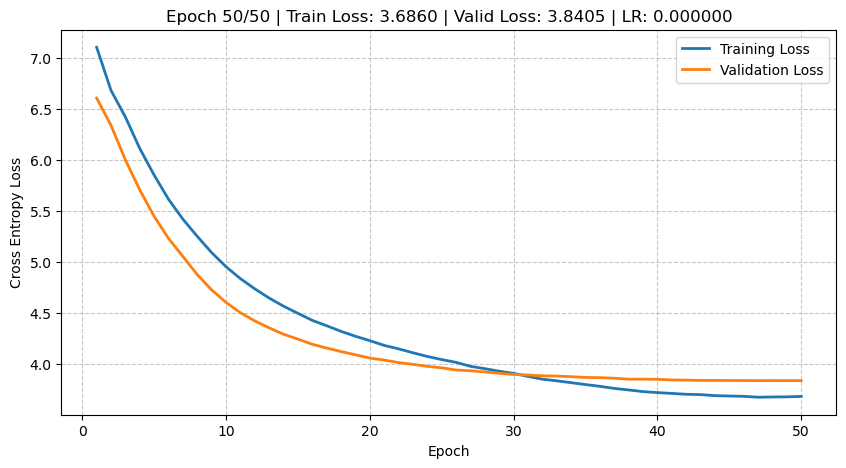

In [12]:
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=wd)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=max_lr, 
    steps_per_epoch=len(ds.batches), 
    epochs=epochs,
    pct_start=0.3
)

train_losses = []
valid_losses = []

for e in range(epochs):
    model.train()
    total_loss, steps = 0.0, 0
    
    for x, y in ds:
        if x.shape == torch.Size([batch_size, seq_len]):
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            
            logits = model(x)
            loss = loss_fn(logits.transpose(1, 2), y)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.25)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            steps += 1
    model.eval()
    model.reset()
    
    with torch.no_grad():
        vloss, v_steps = 0.0, 0
        
        for x, y in valid_ds:
            if x.shape == torch.Size([batch_size, seq_len]):
                x, y = x.to(device), y.to(device)
                logits = model(x)
                vloss += loss_fn(logits.transpose(1, 2), y).item()
                v_steps += 1
                
    model.reset()
    
    train_loss_avg = total_loss / steps
    valid_loss_avg = vloss / v_steps
    current_lr = scheduler.get_last_lr()[0]
    
    train_losses.append(train_loss_avg)
    valid_losses.append(valid_loss_avg)
    
    clear_output(wait=True)
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, e + 2), train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(range(1, e + 2), valid_losses, label='Validation Loss', color='#ff7f0e', linewidth=2)
    
    plt.title(f"Epoch {e+1}/{epochs} | Train Loss: {train_loss_avg:.4f} | Valid Loss: {valid_loss_avg:.4f} | LR: {current_lr:.6f}", fontsize=12)
    plt.xlabel('Epoch', fontsize=10)
    plt.ylabel('Cross Entropy Loss', fontsize=10)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

In [13]:
torch.save(model, f'{str(uuid.uuid4())}.pkl')

In [16]:
import torch.nn.functional as F

def generate_fable(model, prompt, n_words=50, temperature=0.8):
    model.eval()
    model.reset()
    
    tokens = tokenizer.encode(prompt).ids
    
    x = torch.tensor([tokens]).to(device)
    with torch.no_grad():
        out = model(x)
        
    logits = out[0, -1, :]
    
    generated_tokens = []
    
    for _ in range(n_words):
        scaled_logits = logits / temperature
        
        probs = F.softmax(scaled_logits, dim=-1)
        
        next_token = torch.multinomial(probs, num_samples=1).item()
        generated_tokens.append(next_token)
        
        x = torch.tensor([[next_token]]).to(device)
        with torch.no_grad():
            out = model(x)
            logits = out[0, -1, :]
            
    generated_text = tokenizer.decode(generated_tokens)
    
    full_text = f"{prompt} {generated_text}"
    full_text = full_text.replace(" . ", ".\n").replace(" , ", ", ")
    
    return full_text

print(generate_fable(model, "<|titre|>le chien et le chat<|titre|>", n_words=1000, temperature=0.8))

<|titre|>le chien et le chat<|titre|>  
un en loup, le portant d'un coup qui p'en dise
(c’était ce qu'il était sans fale :
c'est les boeufs de son tours :
elle fît à l'heure, et puis sans pié
pour fouer, et d'un jour le dos
tout le haut qu'à la tête de céron,
comme il peut perdu son puissant nez ;
mais quoisez, dit-il, de mombre d'horcurant.
il eût un bon qui pour son lieu de changer
aujourd'hui en retire au maître par la vengeance.
l' aptant de leur hibut, en ce qu'elle fit était chose.
dans le cabinet, faut que lependant
n'yigne plus qu'une patte à ses premiers ;
quand le sens, dit-il, la poule et la souris
de ses flavés ne se les noutont pas.
eux sorte, et l'autre, mais l'un et sa témaine,
pourquoi la vie, et les dieux, puis à ces esprits,
il ne plaît point tout à être faire :
c'est bien se te va placer l'ouvrage.
l'un qui m'édait, et soupir de son hôte,
des plus vérités c'est la légère.
l'un des vers, sultacle, soeur, et la république,
le bon pays, dans son obse cote,
adieu l'honne